In [1]:
# ================================================================
# Heart Disease Prediction — Machine Learning Project
# Author: M U F Ushna | IT23436312 | SLIIT
# Dataset: Heart Disease UCI Dataset (Kaggle)
# Tools: Python, scikit-learn, pandas, matplotlib, seaborn
# GitHub: github.com/Ushna001/Heart-Disease-Prediction-ML
# ================================================================

In [38]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
import joblib

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [39]:
# Load dataset
df = pd.read_csv('dataset_heart.csv')

# Fix column names - remove extra spaces
df.columns = df.columns.str.strip()

# Rename and fix target column
df = df.rename(columns={'heart disease': 'target'})
df['target'] = df['target'].map({1: 0, 2: 1})

print("Dataset Shape:", df.shape)
print("\n📋 First 5 Rows:")
display(df.head())

print("\n Data Types:")
print(df.dtypes)

print("\n Basic Statistics:")
display(df.describe())

print("\n Missing Values:")
print(df.isnull().sum())

print("\n Target Distribution:")
print(df['target'].value_counts())
print(f"\nDisease    (1): {(df['target']==1).sum()}")
print(f"No Disease (0): {(df['target']==0).sum()}")

Dataset Shape: (270, 14)

📋 First 5 Rows:


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,target
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0



 Data Types:
age                                       int64
sex                                       int64
chest pain type                           int64
resting blood pressure                    int64
serum cholestoral                         int64
fasting blood sugar                       int64
resting electrocardiographic results      int64
max heart rate                            int64
exercise induced angina                   int64
oldpeak                                 float64
ST segment                                int64
major vessels                             int64
thal                                      int64
target                                    int64
dtype: object

 Basic Statistics:


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,target
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,0.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,1.000000



 Missing Values:
age                                     0
sex                                     0
chest pain type                         0
resting blood pressure                  0
serum cholestoral                       0
fasting blood sugar                     0
resting electrocardiographic results    0
max heart rate                          0
exercise induced angina                 0
oldpeak                                 0
ST segment                              0
major vessels                           0
thal                                    0
target                                  0
dtype: int64

 Target Distribution:
target
0    150
1    120
Name: count, dtype: int64

Disease    (1): 120
No Disease (0): 150


In [36]:
# Fix column name - rename 'heart disease' to 'target'
df = df.rename(columns={'heart disease': 'target'})

# Also fix target values - this dataset uses 1 and 2 instead of 0 and 1
df['target'] = df['target'].map({1: 0, 2: 1})

print(" Column renamed successfully!")
print("\n Target Distribution:")
print(df['target'].value_counts())
print(f"\nNo Disease (0): {(df['target']==0).sum()}")
print(f"Disease    (1): {(df['target']==1).sum()}")

 Column renamed successfully!

 Target Distribution:
target
0.0    120
Name: count, dtype: int64

No Disease (0): 120
Disease    (1): 0


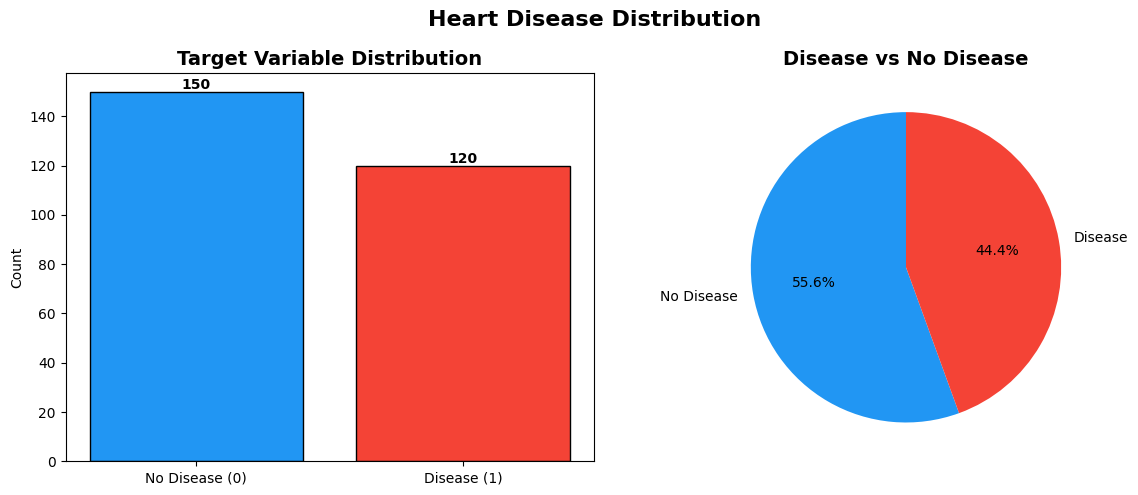

 Plot saved!


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
axes[0].bar(['No Disease (0)', 'Disease (1)'],
            df['target'].value_counts().values,
            color=['#2196F3', '#F44336'], edgecolor='black')
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(df['target'].value_counts().values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(df['target'].value_counts().values,
            labels=['No Disease', 'Disease'],
            colors=['#2196F3', '#F44336'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Disease vs No Disease', fontsize=14, fontweight='bold')

plt.suptitle('Heart Disease Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved!")

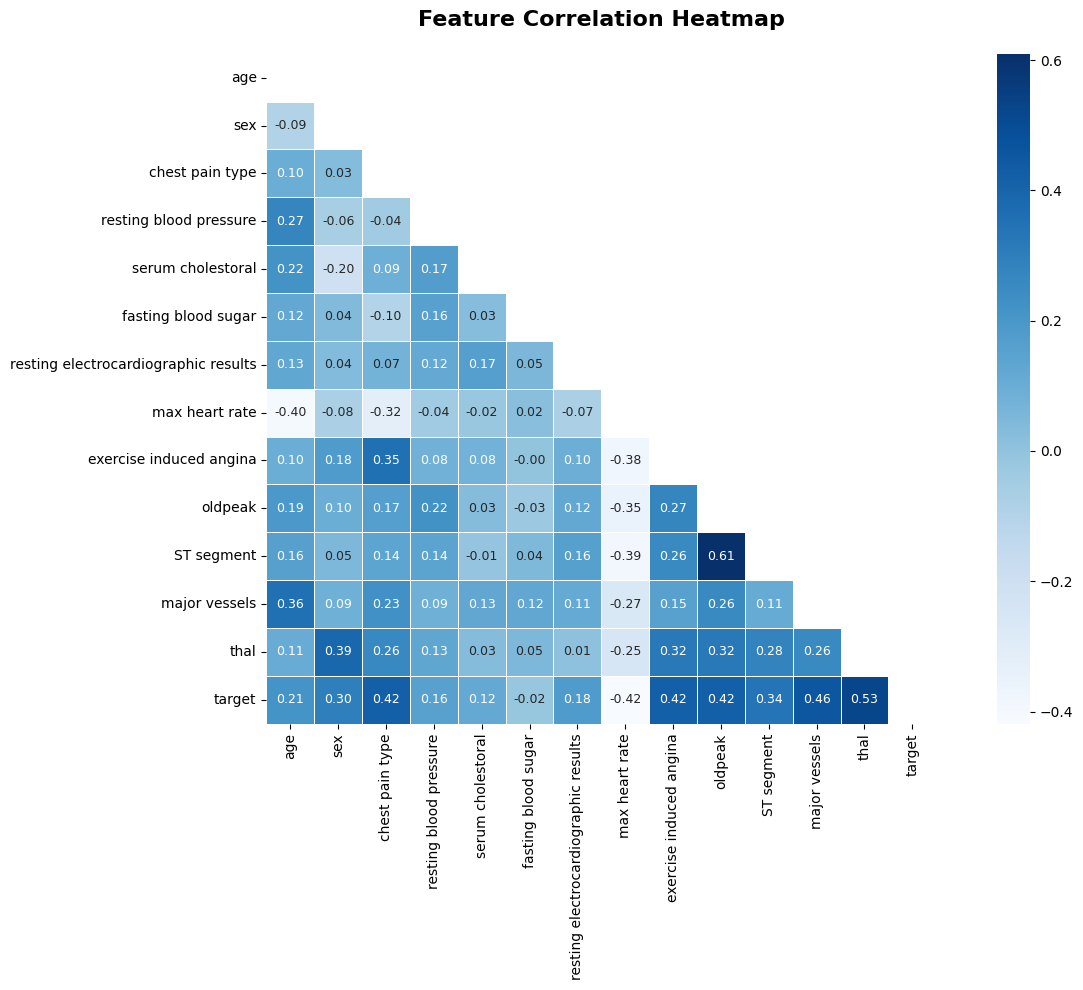

 Heatmap saved!


In [34]:
plt.figure(figsize=(14, 10))
correlation = df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='Blues',
            mask=mask, linewidths=0.5, square=True,
            annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Heatmap saved!")

In [18]:
# Check exact column names
print("Exact column names:")
for col in df.columns:
    print(f"  '{col}'")

Exact column names:
  'age'
  'sex '
  'chest pain type'
  'resting blood pressure'
  'serum cholestoral'
  'fasting blood sugar'
  'resting electrocardiographic results'
  'max heart rate'
  'exercise induced angina'
  'oldpeak'
  'ST segment'
  'major vessels'
  'thal'
  'target'


In [33]:
# Remove all extra spaces from column names
df.columns = df.columns.str.strip()

print(" Fixed column names:")
for col in df.columns:
    print(f"  '{col}'")

 Fixed column names:
  'age'
  'sex'
  'chest pain type'
  'resting blood pressure'
  'serum cholestoral'
  'fasting blood sugar'
  'resting electrocardiographic results'
  'max heart rate'
  'exercise induced angina'
  'oldpeak'
  'ST segment'
  'major vessels'
  'thal'
  'target'


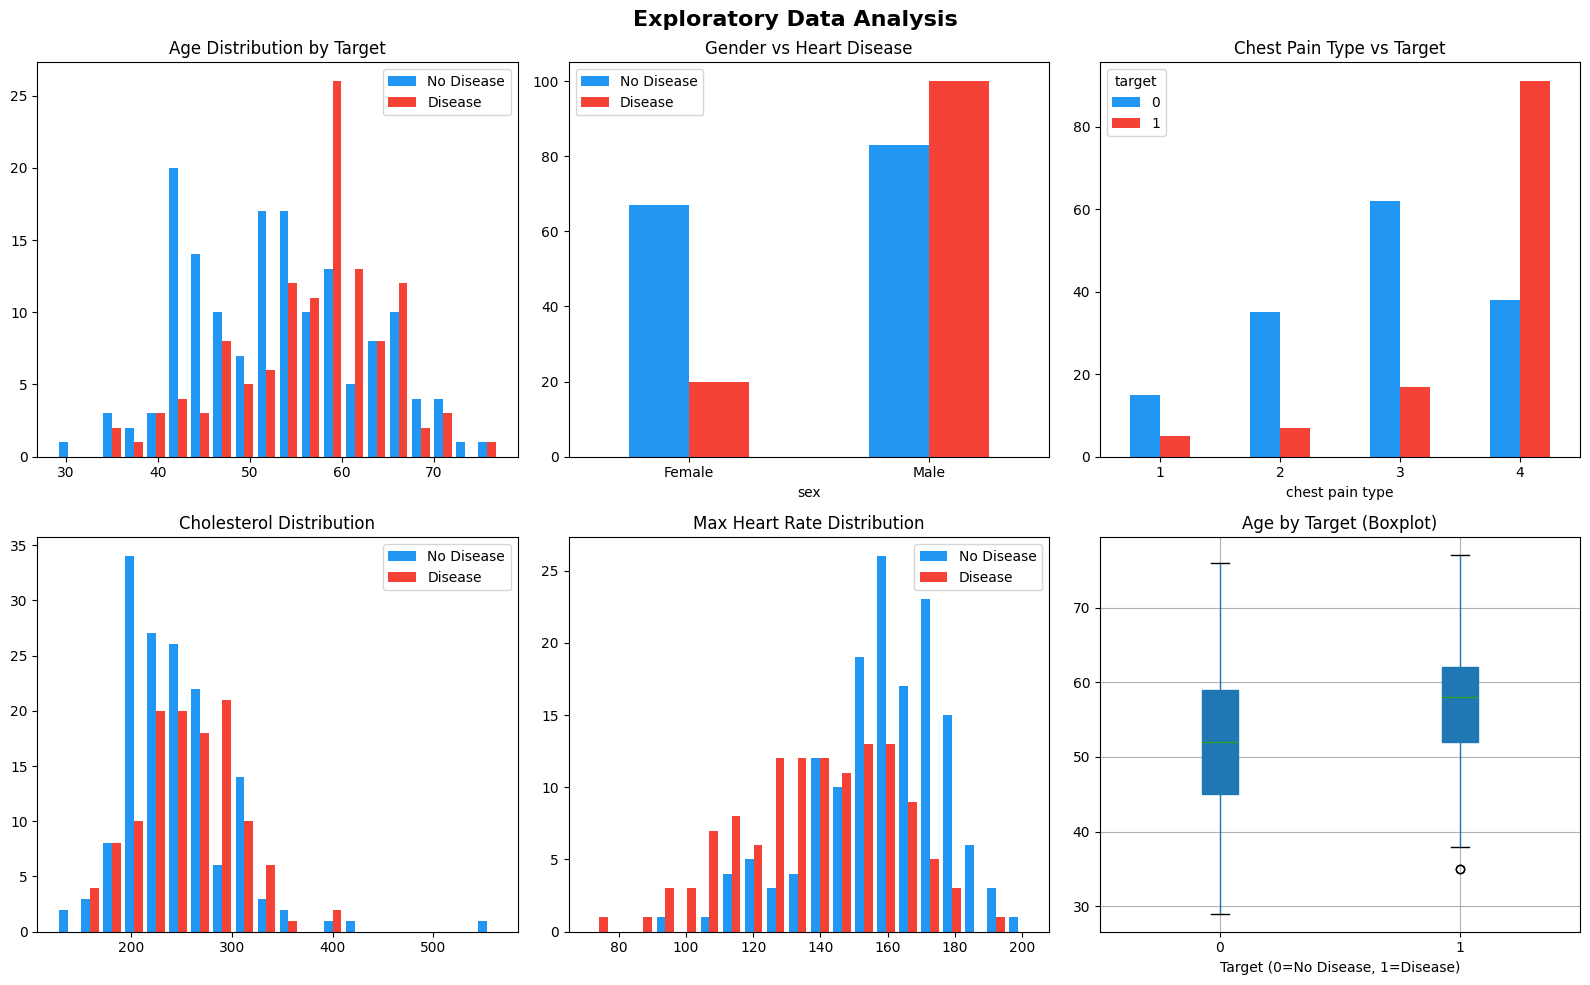

 EDA plots saved!


In [32]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Age vs Target
axes[0,0].hist([df[df['target']==0]['age'], df[df['target']==1]['age']],
               bins=20, color=['#2196F3','#F44336'], label=['No Disease','Disease'])
axes[0,0].set_title('Age Distribution by Target')
axes[0,0].legend()

# Gender vs Target
gender_target = df.groupby(['sex','target']).size().unstack()
gender_target.plot(kind='bar', ax=axes[0,1], color=['#2196F3','#F44336'])
axes[0,1].set_title('Gender vs Heart Disease')
axes[0,1].set_xticklabels(['Female','Male'], rotation=0)
axes[0,1].legend(['No Disease','Disease'])

# Chest Pain vs Target
cp_target = df.groupby(['chest pain type','target']).size().unstack()
cp_target.plot(kind='bar', ax=axes[0,2], color=['#2196F3','#F44336'])
axes[0,2].set_title('Chest Pain Type vs Target')
axes[0,2].tick_params(axis='x', rotation=0)

# Cholesterol
axes[1,0].hist([df[df['target']==0]['serum cholestoral'],
                df[df['target']==1]['serum cholestoral']],
               bins=20, color=['#2196F3','#F44336'], label=['No Disease','Disease'])
axes[1,0].set_title('Cholesterol Distribution')
axes[1,0].legend()

# Max Heart Rate
axes[1,1].hist([df[df['target']==0]['max heart rate'],
                df[df['target']==1]['max heart rate']],
               bins=20, color=['#2196F3','#F44336'], label=['No Disease','Disease'])
axes[1,1].set_title('Max Heart Rate Distribution')
axes[1,1].legend()

# Boxplot Age
df.boxplot(column='age', by='target', ax=axes[1,2], patch_artist=True)
axes[1,2].set_title('Age by Target (Boxplot)')
axes[1,2].set_xlabel('Target (0=No Disease, 1=Disease)')

plt.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(" EDA plots saved!")

In [31]:
# Features and Target
X = df.drop('target', axis=1)
y = df['target']

print(" Features Shape:", X.shape)
print(" Target Shape:", y.shape)
print("\n Feature Columns:", list(X.columns))

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n Training Set: {X_train.shape[0]} samples")
print(f"Testing Set:  {X_test.shape[0]} samples")

 Features Shape: (270, 13)
 Target Shape: (270,)

 Feature Columns: ['age', 'sex', 'chest pain type', 'resting blood pressure', 'serum cholestoral', 'fasting blood sugar', 'resting electrocardiographic results', 'max heart rate', 'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels', 'thal']

 Training Set: 216 samples
Testing Set:  54 samples


In [30]:
# Define all models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
    "SVM":                 SVC(probability=True, random_state=42),
    "KNN":                 KNeighborsClassifier(n_neighbors=5),
    "Decision Tree":       DecisionTreeClassifier(random_state=42)
}

results = {}

print("=" * 60)
print(f"{'Model':<25} {'Accuracy':>10} {'AUC Score':>10}")
print("=" * 60)

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    cv  = cross_val_score(model, X_scaled, y, cv=5).mean()
    results[name] = {'accuracy': acc, 'auc': auc, 'cv_score': cv, 'model': model}
    print(f"{name:<25} {acc:>10.4f} {auc:>10.4f}")

print("=" * 60)
best_name = max(results, key=lambda x: results[x]['accuracy'])
print(f"\n Best Model: {best_name} ({results[best_name]['accuracy']:.4f})")

Model                       Accuracy  AUC Score
Logistic Regression           0.8519     0.8986
Random Forest                 0.8148     0.8701
Gradient Boosting             0.8148     0.8847
SVM                           0.8148     0.8847
KNN                           0.7963     0.8708
Decision Tree                 0.7963     0.8000

 Best Model: Logistic Regression (0.8519)


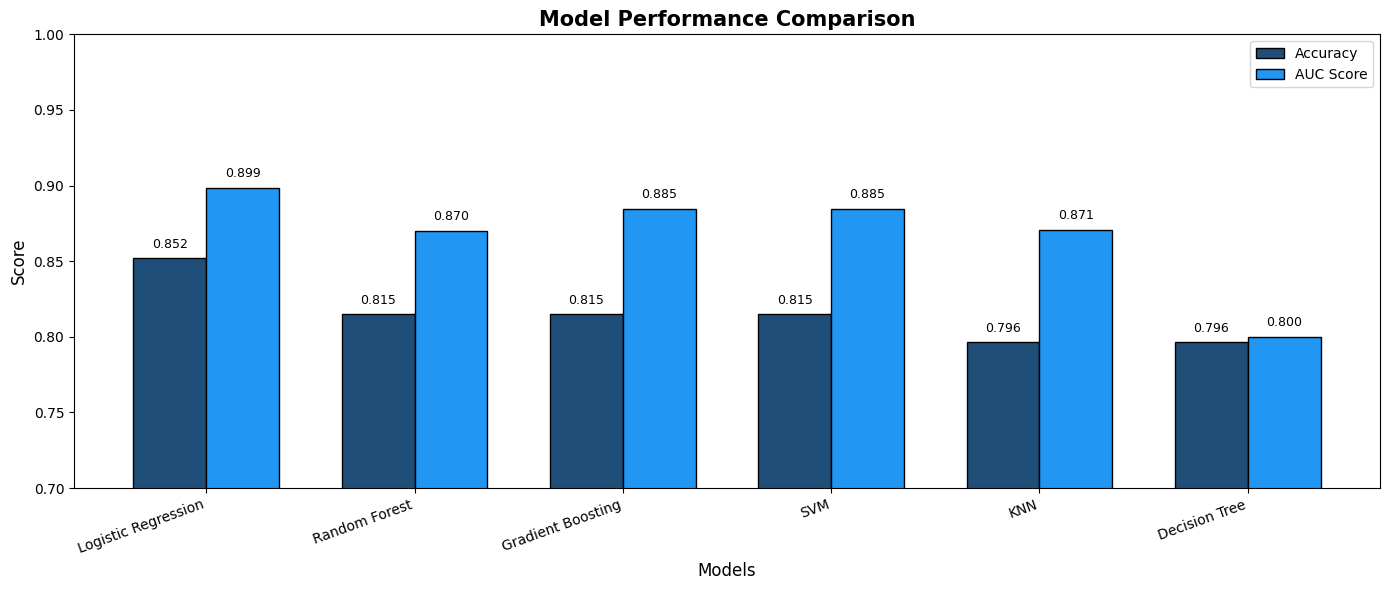

In [23]:
names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in names]
aucs = [results[m]['auc'] for m in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy',
               color='#1F4E79', edgecolor='black')
bars2 = ax.bar(x + width/2, aucs, width, label='AUC Score',
               color='#2196F3', edgecolor='black')

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right')
ax.legend()
ax.set_ylim(0.7, 1.0)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

 Best Model: Logistic Regression
 Accuracy:   0.8519
 AUC Score:  0.8986
 CV Score:   0.8407

 Classification Report:
              precision    recall  f1-score   support

  No Disease       0.92      0.80      0.86        30
     Disease       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54



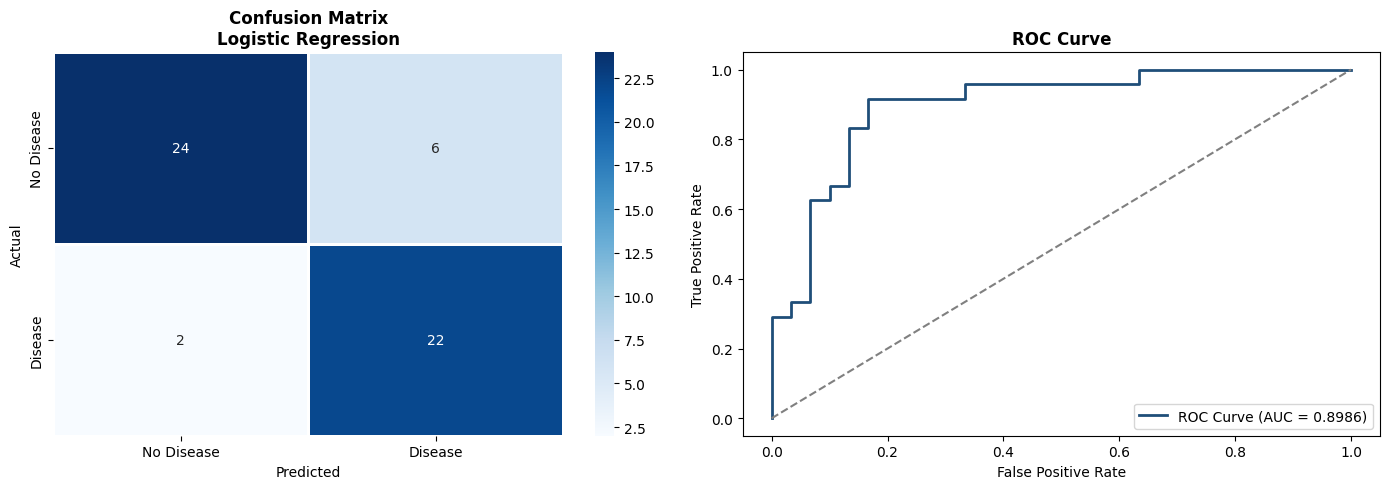

In [29]:
best_model = results[best_name]['model']
best_pred  = best_model.predict(X_test)

print(f" Best Model: {best_name}")
print(f" Accuracy:   {results[best_name]['accuracy']:.4f}")
print(f" AUC Score:  {results[best_name]['auc']:.4f}")
print(f" CV Score:   {results[best_name]['cv_score']:.4f}")
print("\n Classification Report:")
print(classification_report(y_test, best_pred,
      target_names=['No Disease', 'Disease']))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease','Disease'],
            yticklabels=['No Disease','Disease'],
            ax=axes[0], linewidths=2)
axes[0].set_title(f'Confusion Matrix\n{best_name}', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test,
               best_model.predict_proba(X_test)[:,1])
auc_score = roc_auc_score(y_test,
               best_model.predict_proba(X_test)[:,1])
axes[1].plot(fpr, tpr, color='#1F4E79', lw=2,
             label=f'ROC Curve (AUC = {auc_score:.4f})')
axes[1].plot([0,1],[0,1], color='gray', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

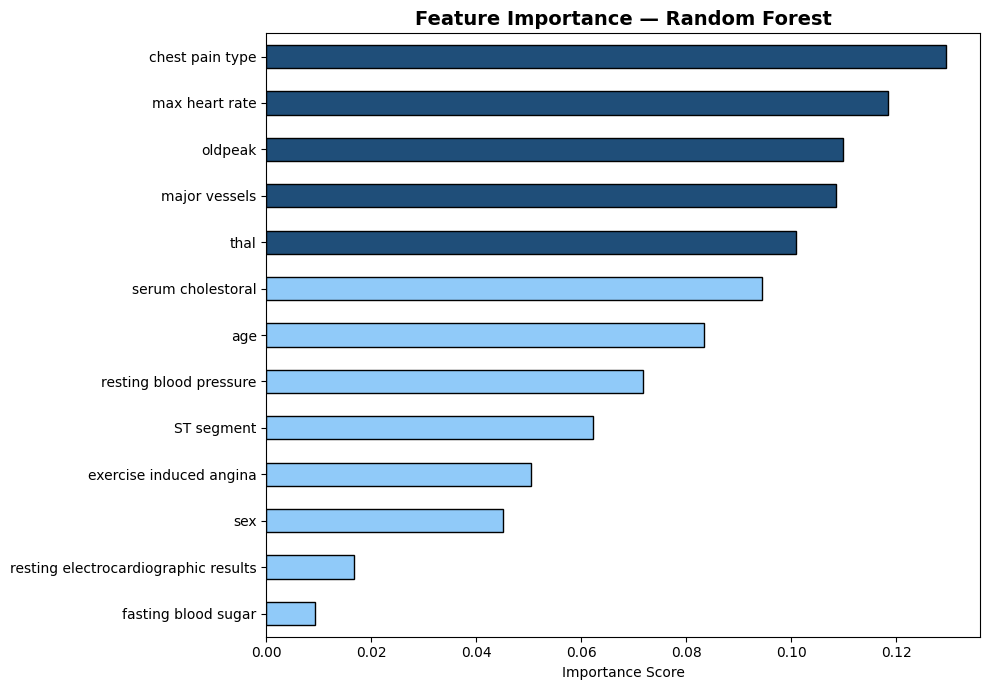


 Top 5 Most Important Features:
chest pain type    0.129436
max heart rate     0.118366
oldpeak            0.109802
major vessels      0.108405
thal               0.100866
dtype: float64


In [28]:
# Use Random Forest for feature importance
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_,
                        index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#1F4E79' if i >= len(importances)-5
          else '#90CAF9' for i in range(len(importances))]
importances.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Feature Importance — Random Forest',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Top 5 Most Important Features:")
print(importances.sort_values(ascending=False).head())

In [27]:
# Save best model and scaler
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print(f" Best model ({best_name}) saved as best_model.pkl")
print(" Scaler saved as scaler.pkl")

# Summary
print("\n" + "="*50)
print("PROJECT SUMMARY")
print("="*50)
print(f"Dataset       : Heart Disease UCI")
print(f"Total Samples : {len(df)}")
print(f"Features      : {X.shape[1]}")
print(f"Best Model    : {best_name}")
print(f"Accuracy      : {results[best_name]['accuracy']:.4f}")
print(f"AUC Score     : {results[best_name]['auc']:.4f}")
print(f"CV Score      : {results[best_name]['cv_score']:.4f}")
print("="*50)

✅ Best model (Logistic Regression) saved as best_model.pkl
✅ Scaler saved as scaler.pkl

PROJECT SUMMARY
Dataset       : Heart Disease UCI
Total Samples : 270
Features      : 13
Best Model    : Logistic Regression
Accuracy      : 0.8519
AUC Score     : 0.8986
CV Score      : 0.8407
